<a href="https://colab.research.google.com/github/livius025/DATA_ANALYSIS_PROJECTS/blob/main/student_performance_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Exam Performance Dataset Analysis


In [192]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Download latest version
path = kagglehub.dataset_download("grandmaster07/student-exam-performance-dataset-analysis")

print("Path to dataset files:", path)

if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0] # Changed index from 1 to 0 to select the CSV file
mydataset


df = pd.read_csv(mydataset)

Using Colab cache for faster access to the 'student-exam-performance-dataset-analysis' dataset.
Path to dataset files: /kaggle/input/student-exam-performance-dataset-analysis
True


# 6-Step Data Wrangling

# A. Discovering

In [193]:
df.head(10)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,67
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,66
8,17,94,Medium,High,No,6,80,High,Yes,0,Medium,Low,Private,Neutral,1,No,College,Near,Male,69
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72


In [194]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

In [195]:
df.shape

(6607, 20)

Identify the numerical features and then display their descriptive statistics.

In [196]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


Examine categorical features

In [197]:
categorical_cols = df.select_dtypes(include='object').columns

if len(categorical_cols) == 0:
    print("No categorical columns found.")
else:
    for col in categorical_cols:
        print(f"\n--- Categorical Feature: {col} ---")
        print(f"Number of unique values: {df[col].nunique()}")
        print("Value Counts:")
        display(df[col].value_counts().head(10)) # Display top 10 for brevity


--- Categorical Feature: Parental_Involvement ---
Number of unique values: 3
Value Counts:


,count
Parental_Involvement,
Medium,3362
High,1908
Low,1337



--- Categorical Feature: Access_to_Resources ---
Number of unique values: 3
Value Counts:


,count
Access_to_Resources,
Medium,3319
High,1975
Low,1313



--- Categorical Feature: Extracurricular_Activities ---
Number of unique values: 2
Value Counts:


...

,count
Parental_Education_Level,
High School,3223
College,1989
Postgraduate,1305



--- Categorical Feature: Distance_from_Home ---
Number of unique values: 3
Value Counts:


,count
Distance_from_Home,
Near,3884
Moderate,1998
Far,658



--- Categorical Feature: Gender ---
Number of unique values: 2
Value Counts:


,count
Gender,
Male,3814
Female,2793


## Questions that this analysis can help answer

* **Academic Impact**: How strongly do `Hours_Studied` and `Attendance` correlate with the final `Exam_Score`?
* **Socioeconomic Factors**: Does `Family_Income` or `Parental_Education_Level` show a significant relationship with student performance?
* **Environmental Factors**: How do `School_Type` (Public vs. Private) and `Teacher_Quality` influence the outcomes?
* **Lifestyle & Motivation**: To what extent do `Sleep_Hours`, `Physical_Activity`, and `Motivation_Level` affect academic success?
* **Peer & Resource Influence**: Does `Internet_Access` or `Peer_Influence` play a role in the variation of scores?

# B. Structuring

Check if the dataset has proper column types

In [198]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

Check if the dataset has index issue

In [199]:
print(df.index)
print(df.index.is_unique)
print(df.index.has_duplicates)

RangeIndex(start=0, stop=6607, step=1)
True
False


Convert columns to correct types

In [200]:
print(df.dtypes)
print(df.head())

Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          9

In [201]:
categorical_cols = ['Parental_Involvement', 'Access_to_Resources',
            'Extracurricular_Activities', 'Motivation_Level',
            'Internet_Access', 'Family_Income', 'Teacher_Quality',
            'School_Type', 'Peer_Influence', 'Learning_Disabilities',
            'Parental_Education_Level', 'Distance_from_Home', 'Gender']
df[categorical_cols] = df[categorical_cols].astype('category')
print(df.dtypes)

Hours_Studied                    int64
Attendance                       int64
Parental_Involvement          category
Access_to_Resources           category
Extracurricular_Activities    category
Sleep_Hours                      int64
Previous_Scores                  int64
Motivation_Level              category
Internet_Access               category
Tutoring_Sessions                int64
Family_Income                 category
Teacher_Quality               category
School_Type                   category
Peer_Influence                category
Physical_Activity                int64
Learning_Disabilities         category
Parental_Education_Level      category
Distance_from_Home            category
Gender                        category
Exam_Score                       int64
dtype: object


In [202]:
# Check exact count of missing values per column
missing_counts = df.isnull().sum()
display(missing_counts[missing_counts > 0])

,0
Teacher_Quality,78
Parental_Education_Level,90
Distance_from_Home,67


In [203]:
# Fixing missing values by filling them with the mode
for col in ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify that there are no more missing values
print('Missing values after fix:')
print(df[['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']].isnull().sum())

Missing values after fix:
Teacher_Quality             0
Parental_Education_Level    0
Distance_from_Home          0
dtype: int64


# C. Cleaning

In [204]:
print(df.isnull().sum())

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


Check for outliers

In [205]:
print(df.describe())

       Hours_Studied   Attendance  Sleep_Hours  Previous_Scores  \
count    6607.000000  6607.000000   6607.00000      6607.000000   
mean       19.975329    79.977448      7.02906        75.070531   
std         5.990594    11.547475      1.46812        14.399784   
min         1.000000    60.000000      4.00000        50.000000   
25%        16.000000    70.000000      6.00000        63.000000   
50%        20.000000    80.000000      7.00000        75.000000   
75%        24.000000    90.000000      8.00000        88.000000   
max        44.000000   100.000000     10.00000       100.000000   

       Tutoring_Sessions  Physical_Activity   Exam_Score  
count        6607.000000        6607.000000  6607.000000  
mean            1.493719           2.967610    67.235659  
std             1.230570           1.031231     3.890456  
min             0.000000           0.000000    55.000000  
25%             1.000000           2.000000    65.000000  
50%             1.000000           3.00000

In [206]:
# Step 1 - Summary stats
print(df.describe())

       Hours_Studied   Attendance  Sleep_Hours  Previous_Scores  \
count    6607.000000  6607.000000   6607.00000      6607.000000   
mean       19.975329    79.977448      7.02906        75.070531   
std         5.990594    11.547475      1.46812        14.399784   
min         1.000000    60.000000      4.00000        50.000000   
25%        16.000000    70.000000      6.00000        63.000000   
50%        20.000000    80.000000      7.00000        75.000000   
75%        24.000000    90.000000      8.00000        88.000000   
max        44.000000   100.000000     10.00000       100.000000   

       Tutoring_Sessions  Physical_Activity   Exam_Score  
count        6607.000000        6607.000000  6607.000000  
mean            1.493719           2.967610    67.235659  
std             1.230570           1.031231     3.890456  
min             0.000000           0.000000    55.000000  
25%             1.000000           2.000000    65.000000  
50%             1.000000           3.00000

In [207]:
# Step 2 - Count outliers using IQR
Q1 = df.select_dtypes(include='int64').quantile(0.25)
Q3 = df.select_dtypes(include='int64').quantile(0.75)
IQR = Q3 - Q1
outliers = ((df.select_dtypes(include='int64') < (Q1 - 1.5 * IQR)) |
            (df.select_dtypes(include='int64') > (Q3 + 1.5 * IQR)))
print(outliers.sum())

Hours_Studied         43
Attendance             0
Sleep_Hours            0
Previous_Scores        0
Tutoring_Sessions    430
Physical_Activity      0
Exam_Score           104
dtype: int64


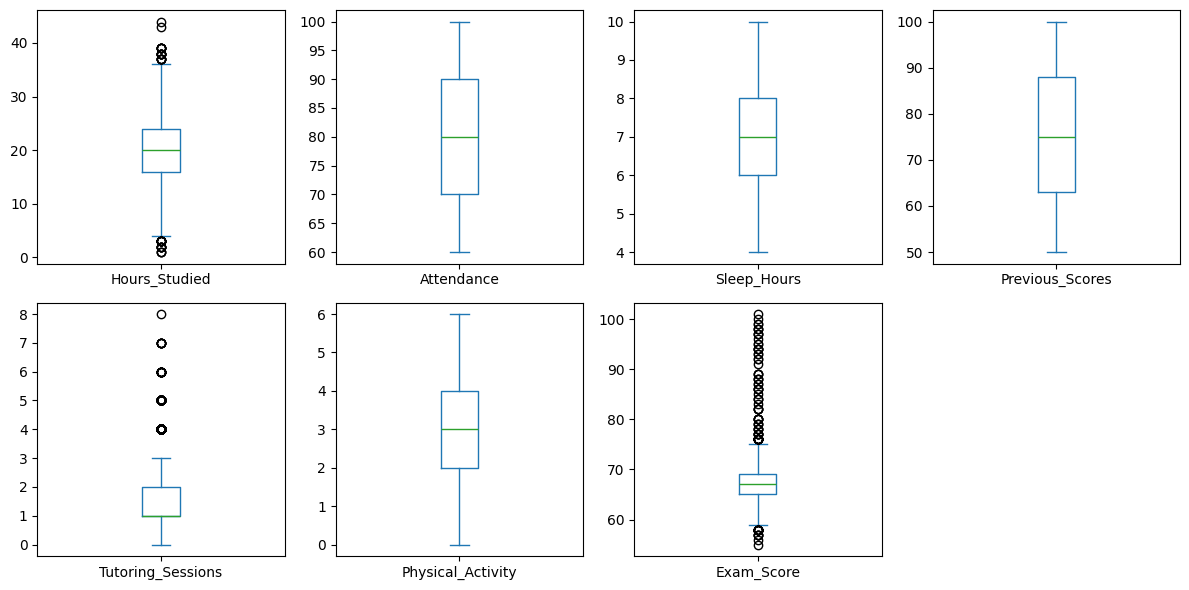

In [208]:
# Step 3 - Visualize
df.select_dtypes(include='int64').plot(kind='box',
                                        figsize=(12, 6),
                                        subplots=True,
                                        layout=(2, 4))
plt.tight_layout()
plt.show()

Check for missing values

In [209]:
# Check unique values
for col in df.select_dtypes(include='category').columns:
    print(f"\n{col}: {df[col].unique().tolist()}")


Parental_Involvement: ['Low', 'Medium', 'High']

Access_to_Resources: ['High', 'Medium', 'Low']

Extracurricular_Activities: ['No', 'Yes']

Motivation_Level: ['Low', 'Medium', 'High']

Internet_Access: ['Yes', 'No']

Family_Income: ['Low', 'Medium', 'High']

Teacher_Quality: ['Medium', 'High', 'Low']

School_Type: ['Public', 'Private']

Peer_Influence: ['Positive', 'Negative', 'Neutral']

Learning_Disabilities: ['No', 'Yes']

Parental_Education_Level: ['High School', 'College', 'Postgraduate']

Distance_from_Home: ['Near', 'Moderate', 'Far']

Gender: ['Male', 'Female']


In [210]:
# Check values counts per categorical column
for col in df.select_dtypes(include='category').columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


Parental_Involvement:
Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64

Access_to_Resources:
Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64

Extracurricular_Activities:
Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64

Motivation_Level:
Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64

Internet_Access:
Internet_Access
Yes    6108
No      499
Name: count, dtype: int64

Family_Income:
Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64

Teacher_Quality:
Teacher_Quality
Medium    4003
High      1947
Low        657
Name: count, dtype: int64

School_Type:
School_Type
Public     4598
Private    2009
Name: count, dtype: int64

Peer_Influence:
Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64

Learning_Disabilities:
Learning_Disabilities
No     5912
Yes     695
Name: 

In [211]:
# Check numeric values for impossible values
# Attendance should be 0-100
print(df[df['Attendance'] < 0 | (df['Attendance'] > 100)])

# Exam_Score should be 0-100
print(df[(df['Exam_Score'] < 0) | (df['Exam_Score'] > 100)])

# Sleep_Hours should be realistic (1-24)
print(df[(df['Sleep_Hours'] < 1) | (df['Sleep_Hours'] > 24)])

# Hours_Studied should be non-negative
print(df[df['Hours_Studied'] < 0])

# Previous_Scores should be 0-100
print(df[(df['Previous_Scores'] < 0) | (df['Previous_Scores'] > 100)])

Empty DataFrame
Columns: [Hours_Studied, Attendance, Parental_Involvement, Access_to_Resources, Extracurricular_Activities, Sleep_Hours, Previous_Scores, Motivation_Level, Internet_Access, Tutoring_Sessions, Family_Income, Teacher_Quality, School_Type, Peer_Influence, Physical_Activity, Learning_Disabilities, Parental_Education_Level, Distance_from_Home, Gender, Exam_Score]
Index: []
      Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
1525             27          98                  Low              Medium   

     Extracurricular_Activities  Sleep_Hours  Previous_Scores  \
1525                        Yes            6               93   

     Motivation_Level Internet_Access  Tutoring_Sessions Family_Income  \
1525              Low              No                  5          High   

     Teacher_Quality School_Type Peer_Influence  Physical_Activity  \
1525            High      Public       Positive                  3   

     Learning_Disabilities Parental_Edu

Apply missing-value strategy(drop, fill, or flag)

In [212]:
df = df[df['Exam_Score'] <= 100]

In [213]:
df.loc[df['Exam_Score'] > 100, 'Exam_Score'] = np.nan

In [214]:
median_score = df['Exam_Score'].median()
df.loc[df['Exam_Score'] > 100, 'Exam_Score'] = median_score

Apply outlier-handling strategy

In [215]:
Q1 = df.select_dtypes(include='int64').quantile(0.25)
Q3 = df.select_dtypes(include='int64').quantile(0.75)
IQR = Q3 - Q1

outliers = ((df.select_dtypes(include='int64') < (Q1 - 1.5 * IQR)) |
            (df.select_dtypes(include='int64') > (Q3 + 1.5 * IQR)))

print(outliers.sum())  # See how many outliers per column

Hours_Studied         43
Attendance             0
Sleep_Hours            0
Previous_Scores        0
Tutoring_Sessions    429
Physical_Activity      0
dtype: int64


In [216]:
# Hours_Studied outliers
Q1_hs = df['Hours_Studied'].quantile(0.25)
Q3_hs = df['Hours_Studied'].quantile(0.75)
IQR_hs = Q3_hs - Q1_hs

print(df[(df['Hours_Studied'] < (Q1_hs - 1.5 * IQR_hs)) |
         (df['Hours_Studied'] > (Q3_hs + 1.5 * IQR_hs))]['Hours_Studied'].value_counts())

# Tutoring_Sessions outliers
Q1_ts = df['Tutoring_Sessions'].quantile(0.25)
Q3_ts = df['Tutoring_Sessions'].quantile(0.75)
IQR_ts = Q3_ts - Q1_ts

print(df[(df['Tutoring_Sessions'] < (Q1_ts - 1.5 * IQR_ts)) |
         (df['Tutoring_Sessions'] > (Q3_ts + 1.5 * IQR_ts))]['Tutoring_Sessions'].value_counts())

Hours_Studied
3     12
38     7
39     7
2      6
37     6
1      3
43     1
44     1
Name: count, dtype: int64
Tutoring_Sessions
4    301
5    102
6     18
7      7
8      1
Name: count, dtype: int64


In [217]:
# Cap Hours_Studied
lower_hs = Q1_hs - 1.5 * IQR_hs
upper_hs = Q3_hs + 1.5 * IQR_hs
df['Hours_Studied'] = df['Hours_Studied'].clip(lower=lower_hs, upper=upper_hs)

# Cap Tutoring_Sessions
lower_ts = Q1_ts - 1.5 * IQR_ts
upper_ts = Q3_ts + 1.5 * IQR_ts
df['Tutoring_Sessions'] = df['Tutoring_Sessions'].clip(lower=lower_ts, upper=upper_ts)

# Verify - should show 0 outliers now
Q1 = df.select_dtypes(include='int64').quantile(0.25)
Q3 = df.select_dtypes(include='int64').quantile(0.75)
IQR = Q3 - Q1
outliers = ((df.select_dtypes(include='int64') < (Q1 - 1.5 * IQR)) |
            (df.select_dtypes(include='int64') > (Q3 + 1.5 * IQR)))
print(outliers.sum())  # Should all be 0

Hours_Studied        0
Attendance           0
Sleep_Hours          0
Previous_Scores      0
Physical_Activity    0
dtype: int64


In [218]:
print(df.dtypes)

Hours_Studied                    int64
Attendance                       int64
Parental_Involvement          category
Access_to_Resources           category
Extracurricular_Activities    category
Sleep_Hours                      int64
Previous_Scores                  int64
Motivation_Level              category
Internet_Access               category
Tutoring_Sessions              float64
Family_Income                 category
Teacher_Quality               category
School_Type                   category
Peer_Influence                category
Physical_Activity                int64
Learning_Disabilities         category
Parental_Education_Level      category
Distance_from_Home            category
Gender                        category
Exam_Score                     float64
dtype: object


In [219]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Series([], dtype: int64)


D. Enriching

Create 3 new variable

In [220]:
# Pass/Fail (based on Exam_Score)
df['Pass_Fail'] = df['Exam_Score'].apply(lambda x: 'Pass' if x >= 50 else 'Fail')

In [221]:
# Sleep Quality (based on Sleep_Hours)
df['Sleep_Quality'] = pd.cut(df['Sleep_Hours'],
                              bins=[0, 5, 7, 9, 24],
                              labels=['Poor', 'Fair', 'Good', 'Oversleep'])

In [222]:
#  Engagement Score (combo of Attendance + Hours_Studied)
df['Engagement_Score'] = (df['Attendance'] + df['Hours_Studied']) / 2

In [223]:
# Verify
print(df[['Exam_Score', 'Pass_Fail',
          'Sleep_Hours', 'Sleep_Quality',
          'Attendance', 'Hours_Studied', 'Engagement_Score']].head(10))

   Exam_Score Pass_Fail  Sleep_Hours Sleep_Quality  Attendance  Hours_Studied  \
0        67.0      Pass            7          Fair          84             23   
1        61.0      Pass            8          Good          64             19   
2        74.0      Pass            7          Fair          98             24   
3        71.0      Pass            8          Good          89             29   
4        70.0      Pass            6          Fair          92             19   
5        71.0      Pass            8          Good          88             19   
6        67.0      Pass            7          Fair          84             29   
7        66.0      Pass            6          Fair          78             25   
8        69.0      Pass            6          Fair          94             17   
9        72.0      Pass            8          Good          98             23   

   Engagement_Score  
0              53.5  
1              41.5  
2              61.0  
3              59.0 

In [224]:
summary = df.groupby(['Pass_Fail', 'Sleep_Quality'], observed=True).agg(
    Count=('Exam_Score', 'count'),
    Avg_Exam_Score=('Exam_Score', 'mean'),
    Avg_Attendance=('Attendance', 'mean'),
    Avg_Hours_Studied=('Hours_Studied', 'mean'),
    Avg_Engagement_Score=('Engagement_Score', 'mean')
).round(2)

print(summary)

                         Count  Avg_Exam_Score  Avg_Attendance  \
Pass_Fail Sleep_Quality                                          
Pass      Poor            1004           67.40           80.66   
          Fair            3116           67.21           79.86   
          Good            2174           67.19           79.88   
          Oversleep        312           67.14           79.56   

                         Avg_Hours_Studied  Avg_Engagement_Score  
Pass_Fail Sleep_Quality                                           
Pass      Poor                       19.95                 50.30  
          Fair                       19.92                 49.89  
          Good                       20.02                 49.95  
          Oversleep                  20.27                 49.92  


# E. Validating

In [225]:
validation_results = []

# Rule 1: Exam_Score must be between 0 and 100
rule1 = df[(df['Exam_Score'] < 0) | (df['Exam_Score'] > 100)]
validation_results.append({'Rule': 'Exam_Score must be between 0-100',
                            'Violations': len(rule1)})

# Rule 2: Attendance must be between 0 and 100
rule2 = df[(df['Attendance'] < 0) | (df['Attendance'] > 100)]
validation_results.append({'Rule': 'Attendance must be between 0-100',
                            'Violations': len(rule2)})

# Rule 3: Hours_Studied must be non-negative
rule3 = df[df['Hours_Studied'] < 0]
validation_results.append({'Rule': 'Hours_Studied must be non-negative',
                            'Violations': len(rule3)})

# Rule 4: Sleep_Hours must be between 1 and 24
rule4 = df[(df['Sleep_Hours'] < 1) | (df['Sleep_Hours'] > 24)]
validation_results.append({'Rule': 'Sleep_Hours must be between 1-24',
                            'Violations': len(rule4)})

# Rule 5: No missing values allowed
rule5 = df.isnull().sum().sum()
validation_results.append({'Rule': 'No missing values allowed',
                            'Violations': rule5})

# Rule 6: No duplicate rows
rule6 = df.duplicated().sum()
validation_results.append({'Rule': 'No duplicate rows',
                            'Violations': rule6})

# Rule 7: Pass_Fail must only contain 'Pass' or 'Fail'
rule7 = df[~df['Pass_Fail'].isin(['Pass', 'Fail'])]
validation_results.append({'Rule': "Pass_Fail must be 'Pass' or 'Fail'",
                            'Violations': len(rule7)})

# Rule 8: Engagement_Score must be non-negative
rule8 = df[df['Engagement_Score'] < 0]
validation_results.append({'Rule': 'Engagement_Score must be non-negative',
                            'Violations': len(rule8)})

# Generate Validation Report
report = pd.DataFrame(validation_results)
report['Status'] = report['Violations'].apply(lambda x: '✅ Pass' if x == 0 else '❌ Fail')
print(report.to_string(index=False))

                                 Rule  Violations Status
     Exam_Score must be between 0-100           0 ✅ Pass
     Attendance must be between 0-100           0 ✅ Pass
   Hours_Studied must be non-negative           0 ✅ Pass
     Sleep_Hours must be between 1-24           0 ✅ Pass
            No missing values allowed           0 ✅ Pass
                    No duplicate rows           0 ✅ Pass
   Pass_Fail must be 'Pass' or 'Fail'           0 ✅ Pass
Engagement_Score must be non-negative           0 ✅ Pass


# F. Publishing

In [226]:
print("=== Final Dataset Summary ===")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"\nNew columns added:")
print(f"  - Pass_Fail: {df['Pass_Fail'].value_counts().to_dict()}")
print(f"  - Sleep_Quality: {df['Sleep_Quality'].value_counts().to_dict()}")
print(f"  - Engagement_Score: min={df['Engagement_Score'].min()}, max={df['Engagement_Score'].max()}")

=== Final Dataset Summary ===
Shape: (6606, 23)
Columns: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score', 'Pass_Fail', 'Sleep_Quality', 'Engagement_Score']
Missing Values: 0
Duplicates: 0

New columns added:
  - Pass_Fail: {'Pass': 6606}
  - Sleep_Quality: {'Fair': 3116, 'Good': 2174, 'Poor': 1004, 'Oversleep': 312}
  - Engagement_Score: min=32.0, max=67.0


Export dataset as CSV

In [227]:
# Save as CSV
df.to_csv('cleaned_student_performance.csv', index=False)
print("\n✅ Dataset successfully saved as 'cleaned_student_performance.csv'!")


✅ Dataset successfully saved as 'cleaned_student_performance.csv'!


Verify the saved dataset

In [228]:
# Reload and check
df_check = pd.read_csv('cleaned_student_performance.csv')
print(df_check.shape)      # Should match original
print(df_check.head())     # Preview first 5 rows

(6606, 23)
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions  ... Peer_Influence Physical_Activity 